# 전처리

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

cust_df=pd.read_csv('santander-customer-satisfaction/train_santander.csv',encoding='latin-1')
print(cust_df.head(3))
print(cust_df.shape)

   ID  var3  var15  imp_ent_var16_ult1  imp_op_var39_comer_ult1  \
0   1     2     23                 0.0                      0.0   
1   3     2     34                 0.0                      0.0   
2   4     2     23                 0.0                      0.0   

   imp_op_var39_comer_ult3  imp_op_var40_comer_ult1  imp_op_var40_comer_ult3  \
0                      0.0                      0.0                      0.0   
1                      0.0                      0.0                      0.0   
2                      0.0                      0.0                      0.0   

   imp_op_var40_efect_ult1  imp_op_var40_efect_ult3  ...  \
0                      0.0                      0.0  ...   
1                      0.0                      0.0  ...   
2                      0.0                      0.0  ...   

   saldo_medio_var33_hace2  saldo_medio_var33_hace3  saldo_medio_var33_ult1  \
0                      0.0                      0.0                     0.0   
1          

In [17]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [22]:
#만족과 불만족비율
cust_df['TARGET'].value_counts(normalize=True)

#비율은 96:4 , 1.지표는 accuracy x ,2.교차검증시 stratified  3.scale_pos_weight(소수에 얼마나 가중치?) 4.학습전 샘플링전략 오버 or 언더 

TARGET
0    0.960431
1    0.039569
Name: proportion, dtype: float64

In [23]:
cust_df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


In [24]:
cust_df['var3'].replace(-999999,2,inplace=True)
cust_df.drop('ID',axis=1,inplace=True)

X_features=cust_df.iloc[:,:-1]
y_labels=cust_df.iloc[:,-1]
print(X_features.shape)

(76020, 369)


C:\Users\rhals\AppData\Local\Temp\ipykernel_30648\3344828746.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cust_df['var3'].replace(-999999,2,inplace=True)


In [37]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X_features,y_labels,test_size=0.2,random_state=42,stratify=y_labels)

print(y_train.value_counts()/y_train.count())
print(y_test.value_counts()/y_test.count())

TARGET
0    0.960438
1    0.039562
Name: count, dtype: float64
TARGET
0    0.960405
1    0.039595
Name: count, dtype: float64


In [39]:
X_tr,X_val,y_tr,y_val=train_test_split(X_train,y_train,test_size=0.3,stratify=y_train,random_state=42)

print(y_tr.value_counts()/y_tr.count())

TARGET
0    0.960443
1    0.039557
Name: count, dtype: float64


In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

# xgb모델 학습과 하이퍼파라미터 튜닝

In [42]:
import xgboost as xgb
from xgboost import plot_importance
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_clf=XGBClassifier(n_estimators=500,early_stopping_rounds=100,metric='auc',random_state=42)
# <metrics 트리가 추가될때마다,val검증셋에서 auc가 어떻게 변하는지 좋아지는지 나빠지는지? early_stop을하기위한 기준으로 봄

evals=[(X_tr,y_tr),(X_val,y_val)]
xgb_clf.fit(X_tr,y_tr,eval_set=evals) 

xgb_roc_score=roc_auc_score(y_test,xgb_clf.predict_proba(X_test)[:,1])
print(xgb_roc_score)

            

[0]	validation_0-logloss:0.14483	validation_1-logloss:0.14778
[1]	validation_0-logloss:0.13879	validation_1-logloss:0.14339
[2]	validation_0-logloss:0.13460	validation_1-logloss:0.14052
[3]	validation_0-logloss:0.13159	validation_1-logloss:0.13892
[4]	validation_0-logloss:0.12917	validation_1-logloss:0.13796
[5]	validation_0-logloss:0.12767	validation_1-logloss:0.13745
[6]	validation_0-logloss:0.12627	validation_1-logloss:0.13695


C:\Users\rhals\anaconda3\Lib\site-packages\xgboost\callback.py:386: UserWarning: [17:19:13] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "metric" } are not used.

  self.starting_round = model.num_boosted_rounds()


[7]	validation_0-logloss:0.12518	validation_1-logloss:0.13668
[8]	validation_0-logloss:0.12418	validation_1-logloss:0.13660
[9]	validation_0-logloss:0.12339	validation_1-logloss:0.13663
[10]	validation_0-logloss:0.12232	validation_1-logloss:0.13676
[11]	validation_0-logloss:0.12142	validation_1-logloss:0.13690
[12]	validation_0-logloss:0.12113	validation_1-logloss:0.13689
[13]	validation_0-logloss:0.12036	validation_1-logloss:0.13695
[14]	validation_0-logloss:0.11979	validation_1-logloss:0.13705
[15]	validation_0-logloss:0.11942	validation_1-logloss:0.13711
[16]	validation_0-logloss:0.11820	validation_1-logloss:0.13735
[17]	validation_0-logloss:0.11797	validation_1-logloss:0.13749
[18]	validation_0-logloss:0.11763	validation_1-logloss:0.13750
[19]	validation_0-logloss:0.11707	validation_1-logloss:0.13736
[20]	validation_0-logloss:0.11690	validation_1-logloss:0.13744
[21]	validation_0-logloss:0.11670	validation_1-logloss:0.13746
[22]	validation_0-logloss:0.11662	validation_1-logloss:0.1

In [45]:
#하이퍼 파라미터 튜닝 space
from hyperopt import hp

xgb_search_space = {'max_depth':hp.quniform('max_depth',5,15,1),
                    'min_child_weight':hp.quniform('min_child_weight',1,6,1),
                    'colsample_bytree':hp.uniform('colsample_bytree',0.5,0.95),
                    'learning_rate':hp.uniform('learning_rate',0.01,0.2)}


In [59]:
#fmin에 사용할 목적함수
# KFold+for문+early stopping
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score


#fmin호출, 교차검증 학습후 -1*roc_auc_score
def objective_func(search_space):
    xgb_clf=XGBClassifier(n_estimators=100,
                          max_depth=int(search_space['max_depth']),
                        min_child_weight=int(search_space['min_child_weight']),
                            colsample_bytre=search_space['colsample_bytree'],
                            learning_rate=search_space['learning_rate'],
                         early_stopping_rounds=30,metric='auc')

    #3개의 k-fold방식으로 평가된 roc_auc지표를 담기
    roc_auc_list=[]
    # k-fold안에서 earlystop을하면 , 최적의 트리개수를 맞췄을때의 각 조합에서의 성능이 최대로 나오는 경우를 비교할수있음
    kf=KFold(n_splits=3)

    for tr_index,val_index  in kf.split(X_train):
        X_tr,y_tr=X_train.iloc[tr_index],y_train.iloc[tr_index]
        X_val,y_val=X_train.iloc[val_index],y_train.iloc[val_index]

        #early stopping은 30으로해서 일찍끝나면 더이상학습 x 
        xgb_clf.fit(X_tr,y_tr,eval_set=([X_tr,y_tr],[X_val,y_val]))

        score=roc_auc_score(y_val,xgb_clf.predict_proba(X_val)[:,1])
        roc_auc_list.append(score)

        #3개의 kfold니까 list의 평균값찾기
        return -1*np.mean(roc_auc_list)


In [60]:
#최적의 하이퍼파라미터 도출

from hyperopt import fmin,tpe,Trials

trials = Trials()

best=fmin(fn=objective_func,space=xgb_search_space,
          algo=tpe.suggest,
          max_evals=50,# 최대반복횟수
          trials=trials,
          rstate=np.random.default_rng(seed=32))
print(best)

[0]	validation_0-logloss:0.15486	validation_1-logloss:0.15747                                                          
[1]	validation_0-logloss:0.14840	validation_1-logloss:0.15201                                                          
[2]	validation_0-logloss:0.14387	validation_1-logloss:0.14825                                                          
[3]	validation_0-logloss:0.14031	validation_1-logloss:0.14559                                                          
  0%|                                                                           | 0/50 [00:00<?, ?trial/s, best loss=?]

C:\Users\rhals\anaconda3\Lib\site-packages\xgboost\callback.py:386: UserWarning: [21:28:21] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "colsample_bytre", "metric" } are not used.

  self.starting_round = model.num_boosted_rounds()



[4]	validation_0-logloss:0.13733	validation_1-logloss:0.14344                                                          
[5]	validation_0-logloss:0.13510	validation_1-logloss:0.14187                                                          
[6]	validation_0-logloss:0.13319	validation_1-logloss:0.14061                                                          
[7]	validation_0-logloss:0.13137	validation_1-logloss:0.13958                                                          
[8]	validation_0-logloss:0.12999	validation_1-logloss:0.13881                                                          
[9]	validation_0-logloss:0.12874	validation_1-logloss:0.13808                                                          
[10]	validation_0-logloss:0.12760	validation_1-logloss:0.13761                                                         
[11]	validation_0-logloss:0.12672	validation_1-logloss:0.13722                                                         
[12]	validation_0-logloss:0.12581	valida

C:\Users\rhals\anaconda3\Lib\site-packages\xgboost\callback.py:386: UserWarning: [21:28:23] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "colsample_bytre", "metric" } are not used.

  self.starting_round = model.num_boosted_rounds()



[7]	validation_0-logloss:0.13909	validation_1-logloss:0.14257                                                          
[8]	validation_0-logloss:0.13794	validation_1-logloss:0.14153                                                          
[9]	validation_0-logloss:0.13688	validation_1-logloss:0.14053                                                          
[10]	validation_0-logloss:0.13588	validation_1-logloss:0.13982                                                         
[11]	validation_0-logloss:0.13501	validation_1-logloss:0.13921                                                         
[12]	validation_0-logloss:0.13432	validation_1-logloss:0.13871                                                         
[13]	validation_0-logloss:0.13364	validation_1-logloss:0.13827                                                         
[14]	validation_0-logloss:0.13309	validation_1-logloss:0.13792                                                         
[15]	validation_0-logloss:0.13254	valida

...

[7]	validation_0-logloss:0.13678	validation_1-logloss:0.14059                                                          
[8]	validation_0-logloss:0.13562	validation_1-logloss:0.13968                                                          
[9]	validation_0-logloss:0.13463	validation_1-logloss:0.13897                                                          
[10]	validation_0-logloss:0.13376	validation_1-logloss:0.13849                                                         
[11]	validation_0-logloss:0.13305	validation_1-logloss:0.13797                                                         
[12]	validation_0-logloss:0.13242	validation_1-logloss:0.13749                                                         
[13]	validation_0-logloss:0.13182	validation_1-logloss:0.13707                                                         
[14]	validation_0-logloss:0.13126	validation_1-logloss:0.13673                                                         
[15]	validation_0-logloss:0.13087	valida

C:\Users\rhals\anaconda3\Lib\site-packages\xgboost\callback.py:386: UserWarning: [21:30:20] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "colsample_bytre", "metric" } are not used.

  self.starting_round = model.num_boosted_rounds()



[2]	validation_0-logloss:0.13923	validation_1-logloss:0.14723                                                          
[3]	validation_0-logloss:0.13481	validation_1-logloss:0.14480                                                          
[4]	validation_0-logloss:0.13143	validation_1-logloss:0.14279                                                          
[5]	validation_0-logloss:0.12856	validation_1-logloss:0.14133                                                          
[6]	validation_0-logloss:0.12597	validation_1-logloss:0.14025                                                          
[7]	validation_0-logloss:0.12385	validation_1-logloss:0.13939                                                          
[8]	validation_0-logloss:0.12157	validation_1-logloss:0.13875                                                          
[9]	validation_0-logloss:0.11986	validation_1-logloss:0.13827                                                          
[10]	validation_0-logloss:0.11815	valida

C:\Users\rhals\anaconda3\Lib\site-packages\xgboost\callback.py:386: UserWarning: [21:30:23] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "colsample_bytre", "metric" } are not used.

  self.starting_round = model.num_boosted_rounds()



[3]	validation_0-logloss:0.14125	validation_1-logloss:0.15004                                                          
[4]	validation_0-logloss:0.13762	validation_1-logloss:0.14801                                                          
[5]	validation_0-logloss:0.13454	validation_1-logloss:0.14631                                                          
[6]	validation_0-logloss:0.13158	validation_1-logloss:0.14482                                                          
[7]	validation_0-logloss:0.12919	validation_1-logloss:0.14353                                                          
[8]	validation_0-logloss:0.12708	validation_1-logloss:0.14261                                                          
[9]	validation_0-logloss:0.12503	validation_1-logloss:0.14178                                                          
[10]	validation_0-logloss:0.12314	validation_1-logloss:0.14110                                                         
[11]	validation_0-logloss:0.12153	valida

In [68]:
# n_estimator=500을 기준으로 최적의 하이퍼 파라미터를 기반으로 학습과 예측

xgb_clf=XGBClassifier(n_estimators=500,learning_rate=best['learning_rate'],max_depth=int(best['max_depth']),min_child_weight=int(best['min_child_weight'])
                      ,colsample_bytree=best['colsample_bytree'],
                      early_stopping_rounds=100,eval_metric='auc')

xgb_clf.fit(X_tr,y_tr,eval_set=([X_tr,y_tr],[X_val,y_val]))

xgb_roc_score=roc_auc_score(y_test,xgb_clf.predict_proba(X_test)[:,1])
print(xgb_roc_score)

[0]	validation_0-auc:0.76520	validation_1-auc:0.73978
[1]	validation_0-auc:0.77595	validation_1-auc:0.75357
[2]	validation_0-auc:0.77890	validation_1-auc:0.76173
[3]	validation_0-auc:0.82357	validation_1-auc:0.80526
[4]	validation_0-auc:0.82307	validation_1-auc:0.80355
[5]	validation_0-auc:0.83316	validation_1-auc:0.81053
[6]	validation_0-auc:0.83875	validation_1-auc:0.81337
[7]	validation_0-auc:0.83801	validation_1-auc:0.81282
[8]	validation_0-auc:0.83968	validation_1-auc:0.81268
[9]	validation_0-auc:0.84387	validation_1-auc:0.81614
[10]	validation_0-auc:0.84544	validation_1-auc:0.81515
[11]	validation_0-auc:0.84926	validation_1-auc:0.81998
[12]	validation_0-auc:0.84948	validation_1-auc:0.81915
[13]	validation_0-auc:0.85002	validation_1-auc:0.81786
[14]	validation_0-auc:0.85064	validation_1-auc:0.81750
[15]	validation_0-auc:0.85090	validation_1-auc:0.81732
[16]	validation_0-auc:0.85119	validation_1-auc:0.81728
[17]	validation_0-auc:0.85149	validation_1-auc:0.81684
[18]	validation_0-au

In [69]:
print(xgb_roc_score)

0.8482232443469038


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

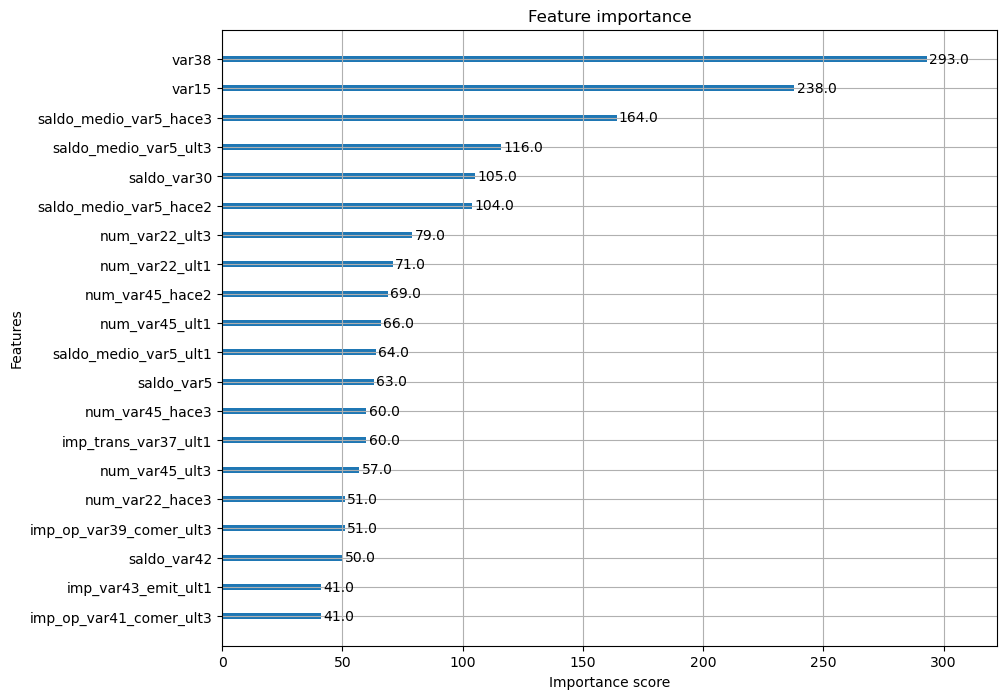

In [72]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig,ax =plt.subplots(1,1,figsize=(10,8))
plot_importance(xgb_clf,ax=ax,max_num_features=20)

# lightgbm

In [83]:
from lightgbm import LGBMClassifier,early_stopping,log_evaluation

lgbm_clf=LGBMClassifier(n_estimators=500,metric='auc',early_stopping_round=100)

evals=[(X_tr,y_tr),(X_val,y_val)]

lgbm_clf.fit(X_tr,y_tr,eval_set=evals)

lgbm_roc_score=roc_auc_score(y_test,lgbm_clf.predict_proba(X_test)[:,1])
print(lgbm_roc_score)

[LightGBM] [Info] Number of positive: 1684, number of negative: 40887
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014365 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13374
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 248
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039557 -> initscore=-3.189640
[LightGBM] [Info] Start training from score -3.189640
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[34]	training's auc: 0.899167	valid_1's auc: 0.832538
0.841753860232135


In [76]:
# lighgbm hyperopt

In [85]:
lgbm_search_space = {'num_leaves': hp.quniform('num_leaves', 32, 64, 1),
                     'max_depth': hp.quniform('max_depth', 100, 160, 1),
                     'min_child_samples': hp.quniform('min_child_samples', 60, 100, 1),
                     'subsample': hp.uniform('subsample', 0.7, 1),
                     'learning_rate': hp.uniform('learning_rate', 0.01, 0.2)
                    }

In [88]:
def objective_func(search_space):
    roc_auc_list = []
    kf = KFold(n_splits=3)
    
    for tr_index, val_index in kf.split(X_train):
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]
        

        lgbm_clf = LGBMClassifier(
            n_estimators=100,
            num_leaves=int(search_space['num_leaves']),
            max_depth=int(search_space['max_depth']),
            min_child_samples=int(search_space['min_child_samples']),
            subsample=search_space['subsample'],
            learning_rate=search_space['learning_rate'],
            metric='auc'
            
        )
        
        lgbm_clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],callbacks=[early_stopping(stopping_rounds=50),log_evaluation(period=1)])
        
        score = roc_auc_score(y_val, lgbm_clf.predict_proba(X_val)[:, 1])
        roc_auc_list.append(score)
    
    return -1*np.mean(roc_auc_list)

In [ ]:
from hyperopt import fmin, tpe, Trials

trials = Trials()

best = fmin(fn=objective_func, space=lgbm_search_space, algo=tpe.suggest,
            max_evals=50, 
            trials=trials, rstate=np.random.default_rng(seed=30))

print('best:', best)

[LightGBM] [Warning] object is set=, object= will be ignored. Current value: object=                                   
[LightGBM] [Warning] at is set=, at= will be ignored. Current value: at=                                               
[LightGBM] [Warning] Unknown parameter: 0x00000201A19975F0>,<lightgbm.callback._LogEvaluationCallback                  
[LightGBM] [Warning] Unknown parameter: callbacks                                                                      
[LightGBM] [Warning] Unknown parameter: object                                                                         
[LightGBM] [Warning] Unknown parameter: at                                                                             
[LightGBM] [Warning] Unknown parameter: 0x00000201EABE0AA0>                                                            
[LightGBM] [Warning] object is set=, object= will be ignored. Current value: object=                                   
[LightGBM] [Warning] at is set=, at= wil

In [ ]:
lgbm_clf = LGBMClassifier(
            n_estimators=500,
            num_leaves=int(best['num_leaves']),
            max_depth=int(best['max_depth']),
            min_child_samples=int(best['min_child_samples']),
            subsample=best['subsample'],
            learning_rate=best['learning_rate'],
            metric='auc'
            
        )
lgbm_clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],callbacks=[early_stopping(stopping_rounds=50),log_evaluation(period=1)])
score = roc_auc_score(y_val, lgbm_clf.predict_proba(X_val)[:, 1])
print(lgbm_score